In [1]:
import polars as pl
import seaborn as sns
from bisect import bisect_left

In [2]:
# ── Tech modeling table ───────────────────────────────────────────────────
tech_path = "../data/model_staging/tech_modeling_table.parquet"
df_tech   = pl.read_parquet(tech_path)
print(f"Tech table shape: {df_tech.shape}")

Tech table shape: (24048, 239)


In [10]:
# ── Load tech modeling table ──
tech_path = '../data/model_staging/tech_modeling_table.parquet'
df_tech = pl.read_parquet(tech_path)
print(f'Tech table: {df_tech.shape} — {len(df_tech.columns)} cols')

# ── Load fundamentals ──
fund_path = '../data/model_staging/fundamentalIndicators/modeling_fundamentals.parquet'
df_fund = pl.read_parquet(fund_path)
df_fund = df_fund.select([
    'symbol',
    pl.col('reportedDate').alias('earnings_date'),
    'eps_growth_qoq', 'revenue_growth_qoq',
    'gross_margin', 'gross_margin_qoq',
    'debt_to_equity', 'debt_to_equity_qoq',
    'fcf_margin', 'fcf_margin_qoq',
    'roe', 'roe_qoq',
    'surprisePercentage',
])
print(f'Fundamentals: {df_fund.shape}')

# ── Load FinBERT transcript sentiment ──
df_finbert = pl.read_parquet('../data/model_staging/finbert_tx_agg_weighted.parquet')
df_finbert = df_finbert.select([
    'symbol',
    pl.col('reportedDate').alias('earnings_date'),
    'pos_prob', 'neg_prob',
])
print(f'FinBERT sentiment: {df_finbert.shape}')

# ── Load news sentiment ──
df_nz = pl.read_parquet('../data/model_staging/nz_sentiment.parquet')
df_nz = df_nz.select([
    'symbol',
    pl.col('reportedDate').alias('earnings_date'),
    'overall_sentiment_score_pre', 'ticker_sentiment_score_pre',
    'overall_sentiment_score_post', 'ticker_sentiment_score_post',
])
print(f'News sentiment: {df_nz.shape}')

# ── Merge ──
df_model = df_tech.join(df_fund, on=['symbol', 'earnings_date'], how='left')
df_model = df_model.join(df_finbert, on=['symbol', 'earnings_date'], how='left')
df_model = df_model.join(df_nz, on=['symbol', 'earnings_date'], how='left')
print(f'\nMerged (pre-sector): {df_model.shape}')

# ── Filter to 2014-2025 only ──
df_model = df_model.filter(
    (pl.col('earnings_date') >= pl.date(2014, 1, 1)) &
    (pl.col('earnings_date') <= pl.date(2025, 12, 31))
)

# ── Sector one-hot ──
df_sector_names = pl.read_parquet('data/sector_info.parquet')
df_sector = df_sector_names.select(['symbol', 'sector']).unique()
df_sector = df_sector.with_columns(pl.col('sector').fill_null('Unknown'))
sectors = sorted(df_sector['sector'].unique().to_list())
df_sector_oh = df_sector.with_columns([
    (pl.col('sector') == s).cast(pl.Int8).alias(f'sector_{s.replace(" ", "_")}')
    for s in sectors
]).drop('sector')

df_model = df_model.join(df_sector_oh, on='symbol', how='left')

print(f'Final merged table: {df_model.shape}')
print(f'  Symbols: {df_model["symbol"].n_unique()}')
print(f'  Date range: {df_model["earnings_date"].min()} to {df_model["earnings_date"].max()}')

Tech table: (24048, 220) — 220 cols
Fundamentals: (24294, 13)
FinBERT sentiment: (24294, 4)
News sentiment: (24294, 6)

Merged (pre-sector): (24048, 237)
Final merged table: (23106, 249)
  Symbols: 502
  Date range: 2014-01-07 to 2025-12-19


In [3]:
df_earnings = pl.read_parquet("../ingestion/data/backup/earnings_delta_backup.parquet")
print(len(df_earnings)) 

24294


In [11]:
urr = df_model.select(['surprisePercentage', 'target_return', 'beat']).drop_nulls().to_pandas()
surr['surprise_clipped'] = surr['surprisePercentage'].clip(-50, 50)

fig, ax = plt.subplots(figsize=(8, 5))

colors_sc = surr['beat'].map({1: GREEN, 0: RED})
ax.scatter(surr['surprise_clipped'], surr['target_return'] * 100,
           c=colors_sc, alpha=0.2, s=5, edgecolors='none')

x, y = surr['surprise_clipped'].values, surr['target_return'].values * 100
mask = ~(np.isnan(x) | np.isnan(y))
coef = np.polyfit(x[mask], y[mask], 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, np.polyval(coef, x_line), color='#333', linewidth=1.5, linestyle='--')

r_val = np.corrcoef(x[mask], y[mask])[0, 1]

ax.set_xlabel('Earnings Surprise % (clipped at ±50%)', fontsize=12)
ax.set_ylabel('Peak Return (%)', fontsize=12)
ax.set_ylim(-20, 80)  # adjust these values as needed
ax.set_title(f'Earnings Surprise vs. Post-Earnings Drift\nPearson r = {r_val:.3f} (no linear relationship)',
             fontsize=14, fontweight='bold', color=NAVY, loc='left', pad=12)

from matplotlib.lines import Line2D
leg_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=GREEN, markersize=8, label='Beat'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=RED, markersize=8, label='Miss'),
]
ax.legend(handles=leg_elements, fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/surprise_vs_return.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'r = {r_val:.3f} — EPS surprise alone cannot predict drift. Non-linear ML is required.')

ColumnNotFoundError: unable to find column "beat"; valid columns: ["symbol", "earnings_date", "target_return", "target_direction", "open_pct_t-10", "high_pct_t-10", "low_pct_t-10", "volume_rel_t-10", "rsi_t-10", "macd_t-10", "macd_hist_t-10", "roc_t-10", "ema50_pct_t-10", "ema200_pct_t-10", "ema50_200_pct_t-10", "adx_t-10", "atr_t-10", "bb_width_t-10", "bb_pct_b_t-10", "sigma_t-10", "obv_zscore_t-10", "vwap_pct_t-10", "open_pct_t-9", "high_pct_t-9", "low_pct_t-9", "volume_rel_t-9", "rsi_t-9", "macd_t-9", "macd_hist_t-9", "roc_t-9", "ema50_pct_t-9", "ema200_pct_t-9", "ema50_200_pct_t-9", "adx_t-9", "atr_t-9", "bb_width_t-9", "bb_pct_b_t-9", "sigma_t-9", "obv_zscore_t-9", "vwap_pct_t-9", "open_pct_t-8", "high_pct_t-8", "low_pct_t-8", "volume_rel_t-8", "rsi_t-8", "macd_t-8", "macd_hist_t-8", "roc_t-8", "ema50_pct_t-8", "ema200_pct_t-8", "ema50_200_pct_t-8", "adx_t-8", "atr_t-8", "bb_width_t-8", "bb_pct_b_t-8", "sigma_t-8", "obv_zscore_t-8", "vwap_pct_t-8", "open_pct_t-7", "high_pct_t-7", 

In [5]:
df_tech = pl.read_parquet("../data/model_staging/tech_modeling_table.parquet")
df_earnings = df_earnings.with_columns(pl.col("reportedDate").alias("earnings_date"))
missing = df_earnings.join(df_tech, on=["symbol", "earnings_date"], how="anti", suffix="_tech")
print(len(missing))  # should be 246
missing.group_by("symbol").len().sort("len", descending=True).head(20)

246


symbol,len
str,u32
"""BRK-B""",29
"""DOW""",20
"""ON""",19
"""SNDK""",15
"""IR""",15
…,…
"""CTVA""",3
"""SMCI""",3
"""NDSN""",3


In [8]:
df_ohlcv = pl.read_parquet("../ingestion/data/backup/ohlcv_delta_backup.parquet")
for row in missing.iter_rows(named=True):
    sym_daily = df_ohlcv.filter(pl.col("symbol") == row["symbol"]).sort("date")
    dates = sym_daily["date"].to_list()
    t0 = bisect_left(dates, row["earnings_date"])
    reason = "date not in OHLCV" if (t0 >= len(dates) or dates[t0] != row["earnings_date"]) else \
             "no ±10 trading days" if (t0 - 10 < 0 or t0 + 10 >= len(dates)) else "UNKNOWN"
    print(f"{row['symbol']} {row['earnings_date']}  → {reason}")

BRK-B 2019-05-04  → date not in OHLCV
BRK-B 2017-02-25  → date not in OHLCV
BRK-B 2023-08-05  → date not in OHLCV
BRK-B 2022-11-05  → date not in OHLCV
BRK-B 2020-11-07  → date not in OHLCV
BRK-B 2020-08-08  → date not in OHLCV
BRK-B 2014-03-01  → date not in OHLCV
BRK-B 2024-02-24  → date not in OHLCV
BRK-B 2020-02-22  → date not in OHLCV
BRK-B 2019-11-03  → date not in OHLCV
BRK-B 2018-11-03  → date not in OHLCV
BRK-B 2018-08-04  → date not in OHLCV
BRK-B 2018-02-24  → date not in OHLCV
BRK-B 2023-11-04  → date not in OHLCV
BRK-B 2022-04-30  → date not in OHLCV
BRK-B 2018-05-05  → date not in OHLCV
BRK-B 2026-05-02  → date not in OHLCV
BRK-B 2024-05-04  → date not in OHLCV
BRK-B 2023-02-25  → date not in OHLCV
BRK-B 2021-08-07  → date not in OHLCV
BRK-B 2020-05-02  → date not in OHLCV
BRK-B 2015-02-28  → date not in OHLCV
BRK-B 2021-11-07  → date not in OHLCV
BRK-B 2021-05-01  → date not in OHLCV
BRK-B 2021-02-27  → date not in OHLCV
BRK-B 2019-02-23  → date not in OHLCV
BRK-B 2016-0

In [3]:
df_tech.head(5)

symbol,earnings_date,entry_price,target_return,target_class,car_3day,car_t2_t10,max_high,min_high,max_day,min_day,open_pct_t-10,high_pct_t-10,low_pct_t-10,volume_rel_t-10,rsi_t-10,macd_t-10,macd_hist_t-10,roc_t-10,ema50_pct_t-10,ema200_pct_t-10,ema50_200_pct_t-10,adx_t-10,atr_t-10,bb_width_t-10,bb_pct_b_t-10,sigma_t-10,obv_zscore_t-10,vwap_pct_t-10,vix_close_t-10,open_pct_t-9,high_pct_t-9,low_pct_t-9,volume_rel_t-9,rsi_t-9,macd_t-9,macd_hist_t-9,…,high_pct_t0,low_pct_t0,volume_rel_t0,rsi_t0,macd_t0,macd_hist_t0,roc_t0,ema50_pct_t0,ema200_pct_t0,ema50_200_pct_t0,adx_t0,atr_t0,bb_width_t0,bb_pct_b_t0,sigma_t0,obv_zscore_t0,vwap_pct_t0,vix_close_t0,open_pct_t+1,high_pct_t+1,low_pct_t+1,volume_rel_t+1,rsi_t+1,macd_t+1,macd_hist_t+1,roc_t+1,ema50_pct_t+1,ema200_pct_t+1,ema50_200_pct_t+1,adx_t+1,atr_t+1,bb_width_t+1,bb_pct_b_t+1,sigma_t+1,obv_zscore_t+1,vwap_pct_t+1,vix_close_t+1
str,date,f64,f64,i64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""LYB""",2020-07-31,42.475105,0.183004,2,-0.099336,0.084218,50.248203,44.539732,7,2,0.008175,0.017518,-0.006131,-0.466738,56.244829,0.011621,0.002661,2.299903,0.060346,-0.007481,-0.063967,10.51737,0.040626,0.100177,0.794481,0.020628,-0.306764,0.047946,25.68,0.019012,0.032036,-0.002545,-0.432572,51.672713,0.010835,0.001317,…,0.034389,-0.015995,0.668771,39.213279,0.001579,-0.008466,-8.72993,-0.045096,-0.092035,-0.049156,9.797605,0.040911,0.105249,-0.219292,0.022621,-0.392894,-0.063225,24.459999,0.014808,0.02704,-0.000322,0.344674,38.427014,-0.004488,-0.011676,-6.991045,-0.049149,-0.096821,-0.050136,11.404466,0.040181,0.135342,-0.067169,0.021281,-0.61579,-0.063568,24.280001
"""LYB""",2023-10-27,76.03109,0.036976,1,0.019794,-0.022796,78.842392,76.131806,10,3,0.003776,0.014674,-0.0041,-0.323695,42.163044,-0.013228,-0.001008,-2.133043,-0.023657,0.015104,0.039701,30.334723,0.022799,0.054506,0.389251,0.013491,0.762318,-0.018973,19.32,0.001927,0.007173,-0.006745,-0.421522,45.343562,-0.012117,0.000006,…,0.009951,-0.021893,0.495901,41.020603,-0.015152,-0.002034,-2.416901,-0.036189,-0.009893,0.027284,33.333808,0.022381,0.07041,0.231914,0.013056,0.800155,-0.017975,21.27,0.008057,0.010265,-0.02064,0.147614,41.6783,-0.014836,-0.001394,-3.008253,-0.033177,-0.008061,0.025978,34.210997,0.022954,0.069164,0.289271,0.012625,0.899396,-0.01437,19.75
"""LYB""",2021-04-30,76.533699,0.082507,2,0.013232,0.061157,82.848248,77.569582,6,2,0.00623,0.014877,-0.006137,-0.281581,58.323214,0.007363,0.001179,1.894857,0.051681,0.227514,0.167193,10.782928,0.027548,0.050157,0.983224,0.011011,1.457469,0.027006,16.25,0.005037,0.007929,-0.0125,-0.414743,57.146784,0.008037,0.001466,…,0.031617,-0.004916,0.197002,47.115412,0.002745,-0.001357,-3.542539,0.004395,0.161622,0.15654,8.167558,0.029258,0.065117,0.213504,0.023265,1.320815,-0.012261,18.610001,-0.02707,0.010568,-0.033281,0.455346,55.25571,0.004287,0.000273,0.625,0.042566,0.205374,0.156161,8.139122,0.029617,0.066959,0.770946,0.025388,1.439035,0.024624,18.309999
"""LYB""",2026-01-30,49.647209,0.200597,2,-0.003609,0.164302,59.606293,54.063588,9,2,0.017689,0.022013,-0.010417,0.123886,67.715871,0.031434,0.015227,17.505782,0.113001,-0.021563,-0.120902,24.256664,0.034681,0.240393,0.892881,0.026488,-0.426012,0.106018,15.84,-0.010411,0.002946,-0.018071,-0.181901,67.787401,0.03404,0.014274,…,0.05,-0.04449,1.775117,52.852446,0.02798,-0.003896,-3.69497,0.036541,-0.055073,-0.088385,26.647695,0.040106,0.093137,0.216866,0.028438,-1.333777,-0.002721,17.440001,-0.031045,0.005771,-0.06209,0.505643,57.49958,0.025976,-0.004086,-1.296401,0.060365,-0.030669,-0.085851,25.059181,0.041162,0.08039,0.4449,0.028923,-1.060137,0.016309,16.34
"""LYB""",2014-07-25,59.133503,0.006658,0,0.072889,0.012761,59.527211,57.682816,2,5,-0.005647,0.002622,-0.008673,-0.380869,53.819639,0.001954

In [ ]:
# distribution of max_high 
# ----- the days taken for the target to be reached from t+1
df_tech['max_day'].describe()



statistic,value
str,f64
"""count""",24048.0
"""null_count""",0.0
"""mean""",6.103418
"""std""",3.082486
"""min""",2.0
"""25%""",3.0
"""50%""",6.0
"""75%""",9.0
"""max""",10.0


<Axes: ylabel='Count'>

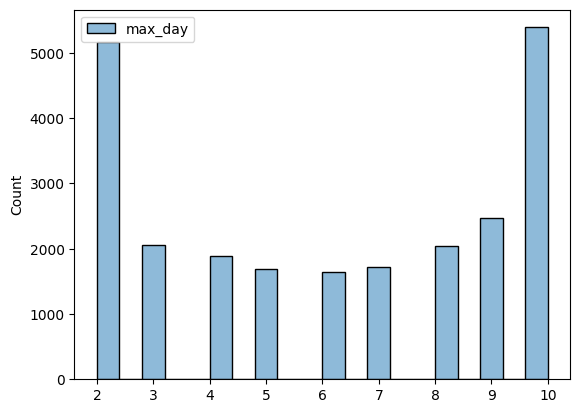

In [11]:
#plot of max_day distribution
sns.histplot(df_tech.select(pl.col("max_day")).to_pandas() )

In [6]:
# read the parquet file into a polars dataframe
df_ohlcv = pl.read_parquet("../ingestion/data/backup/ohlcv_delta_backup.parquet")

df_ohlcv.head(5)

symbol,date,open,high,low,close,volume
str,date,f64,f64,f64,f64,i64
"""BRK-B""",2011-01-27,82.739998,83.239998,82.650002,83.029999,2817800
"""BRK-B""",2013-02-28,101.440002,102.330002,101.309998,102.160004,8875500
"""BRK-B""",2013-03-01,101.449997,102.25,100.440002,102.050003,4812800
"""BRK-B""",2013-03-06,103.290001,103.559998,102.760002,103.239998,3316300
"""BRK-B""",2013-03-15,103.669998,103.790001,102.790001,102.790001,7253800


In [5]:
df_tech = df_tech.join(df_ohlcv, left_on=["symbol", "earnings_date"], right_on=["symbol", "date"], how="left")

In [6]:
df_tech.filter(pl.col('symbol') == 'NVDA').sort('earnings_date', descending=True)

symbol,earnings_date,entry_price,target_return,target_class,car_3day,car_t2_t10,max_high,min_high,max_day,min_day,open_pct_t-10,high_pct_t-10,low_pct_t-10,volume_rel_t-10,rsi_t-10,macd_t-10,macd_hist_t-10,roc_t-10,ema50_pct_t-10,ema200_pct_t-10,ema50_200_pct_t-10,adx_t-10,atr_t-10,bb_width_t-10,bb_pct_b_t-10,sigma_t-10,obv_zscore_t-10,vwap_pct_t-10,vix_close_t-10,open_pct_t-9,high_pct_t-9,low_pct_t-9,volume_rel_t-9,rsi_t-9,macd_t-9,macd_hist_t-9,…,macd_hist_t0,roc_t0,ema50_pct_t0,ema200_pct_t0,ema50_200_pct_t0,adx_t0,atr_t0,bb_width_t0,bb_pct_b_t0,sigma_t0,obv_zscore_t0,vwap_pct_t0,vix_close_t0,open_pct_t+1,high_pct_t+1,low_pct_t+1,volume_rel_t+1,rsi_t+1,macd_t+1,macd_hist_t+1,roc_t+1,ema50_pct_t+1,ema200_pct_t+1,ema50_200_pct_t+1,adx_t+1,atr_t+1,bb_width_t+1,bb_pct_b_t+1,sigma_t+1,obv_zscore_t+1,vwap_pct_t+1,vix_close_t+1,open,high,low,close,volume
str,date,f64,f64,i64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
"""NVDA""",2026-02-25,184.87999,0.01482,0,-0.044145,0.027894,187.619995,180.890198,10,4,0.015063,0.020897,-0.002228,-0.22643,53.739993,-0.00067,0.000289,0.010604,0.020394,0.105194,0.083106,12.949792,0.034634,0.129041,0.621938,0.027488,0.529569,0.021033,17.790001,0.012628,0.01689,-0.006735,-0.180724,55.16037,0.001568,0.002015,…,0.00517,3.723349,0.049807,0.13462,0.080789,9.479283,0.030064,0.114931,0.869529,0.023432,1.086218,0.04642,17.93,0.050733,0.050841,-0.003083,0.906483,47.358981,0.007466,0.00223,-2.715079,-0.007181,0.071938,0.079691,9.613993,0.03387,0.070613,0.227155,0.028124,0.789787,-0.0087,18.629999,194.439467,197.619303,193.7795,195.549408,250637100
"""NVDA""",2025-11-19,180.620163,0.02779,1,-0.011085,-0.031396,185.639614,178.140435,8,4,0.018237,0.039496,-0.002869,-0.072622,54.861741,0.026876,0.004549,8.28157,0.055505,0.236752,0.171716,21.089325,0.034234,0.203527,0.557292,0.022816,1.399377,0.019554,18.01,0.044343,0.050723,-0.009039,0.19414,47.854556,0.022467,-0.000565,…,-0.009714,-4.451629,0.001128,0.159697,0.158391,16.129279,0.040049,0.143356,0.27824,0.028072,1.344407,-0.03838,23.66,0.084754,0.085031,-0.004373,0.643151,42.750837,-0.004577,-0.011146,-3.955769,-0.029274,0.121763,0.155592,15.017332,0.044785,0.145935,0.125487,0.028821,1.070487,-0.064933,26.42,184.769691,187.839361,182.809915,186.499512,247246400
"""NVDA""",2025-08-27,180.14006,0.000667,0,-0.007591,-0.027953,180.260218,169.001924,10,6,0.005672,0.013106,-0.012335,0.158863,65.772509,0.032819,-0.002288,1.294127,0.113052,0.324431,0.18991,44.372911,0.023981,0.067739,0.722092,0.014765,2.091209,0.028582,14.49,-0.012471,0.005494,-0.014064,-0.156822,66.296477,0.031519,-0.002804,…,-0.004345,0.005513,0.078171,0.286934,0.193627,29.568114,0.025001,0.061524,0.636805,0.012367,1.746104,0.01269,14.85,0.003608,0.023866,-0.020869,0.674501,57.579498,0.015166,-0.004167,-1.016368,0.066766,0.273293,0.193602,28.464818,0.026595,0.059458,0.524908,0.012188,1.495535,0.003783,14.43,181.949751,182.459676,179.07024,181.569824,235518900
"""NVDA""",2025-05-28,139.157211,0.041742,2,0.040565,0.008557,144.965904,138.087457,10,3,-0.038097,0.009928,-0.042023,0.439084,69.93285,0.025861,0.017658,19.179969,0.134567,0.104809,-0.026229,16.400368,0.042821,0.211265,1.142598,0.023772,0.324168,0.176589,18.219999,-0.015812,0.000739,-0.027043,0.210827,73.394498,0.033934,0.020847,…,0.003685,3.755877,0.114309,0.13115,0.015114,28.310337,0.034365,0.196909,0.66285,0.024091,0.163334,0.067957,19.309999,0.021984,0.030893,-0.009196,0.669406,70.667878,0.046454,0.004058,2.844697,0.143762,0.165954,0.019403,29.945759,0.03536,0.170164,0.811663,0.024624,0.614167,0.085445,19.18,135.997958,137.217672,134.758244,134.778244,304021100
"""NVDA""",2025-02-26,120.110649,0.041115,2,-0.055668,0.017794,125.049017,111.813353,2,8,-0.001657,0.012651,-0.013404,-0.406575,51.280852,-0.017032,0.0056

In [7]:
df_tech.filter(pl.col('symbol') == 'NVDA').sort('earnings_date', descending=True).select([
    pl.col("symbol"),
    pl.col("earnings_date"),
    pl.col("close"),
    #pl.col("^ema.*$"),
    pl.col("ema50_pct_t0"),
    pl.col("ema200_pct_t0")
])

symbol,earnings_date,close,ema50_pct_t0,ema200_pct_t0
str,date,f64,f64,f64
"""NVDA""",2026-02-25,195.549408,0.049807,0.13462
"""NVDA""",2025-11-19,186.499512,0.001128,0.159697
"""NVDA""",2025-08-27,181.569824,0.078171,0.286934
"""NVDA""",2025-05-28,134.778244,0.114309,0.13115
"""NVDA""",2025-02-26,131.237,-0.017838,0.078695
…,…,…,…,…
"""NVDA""",2015-02-11,0.499301,0.038624,0.095374
"""NVDA""",2014-11-06,0.4831,0.081663,0.122673
"""NVDA""",2014-08-07,0.415321,-0.049883,0.003262


In [20]:
# model predictions output
df_pred = pl.read_csv("../data/multitask_dnn_default_predictions.csv")

In [22]:
df_pred.write_clipboard()

In [23]:
df_pred

quarter,fold_num,symbol,earnings_date,entry_price,target_class_actual,target_class_predicted,prob_class_0,prob_class_1,prob_class_2,target_return_actual,target_return_predicted
str,i64,str,str,f64,i64,i64,f64,f64,f64,f64,f64
"""2021_Q1""",5,"""LYB""","""2021-01-29""",60.94038,2,2,0.113442,0.204643,0.681915,0.113199,0.064758
"""2021_Q1""",5,"""CPRT""","""2021-02-18""",29.2675,0,2,0.143203,0.241099,0.615698,-0.007175,0.061401
"""2021_Q1""",5,"""LIN""","""2021-02-05""",239.364243,0,2,0.256704,0.325801,0.417495,0.002837,0.037548
"""2021_Q1""",5,"""HBAN""","""2021-01-22""",10.690092,2,2,0.162107,0.250041,0.587852,0.061573,0.056834
"""2021_Q1""",5,"""VZ""","""2021-01-26""",39.989746,1,2,0.219071,0.299053,0.481876,0.021767,0.041641
…,…,…,…,…,…,…,…,…,…,…,…
"""2025_Q4""",24,"""BR""","""2025-11-04""",216.46933,2,2,0.285965,0.347307,0.366727,0.045521,0.039748
"""2025_Q4""",24,"""PCAR""","""2025-10-21""",97.656738,0,2,0.301975,0.34224,0.355785,0.018938,0.038797
"""2025_Q4""",24,"""TXT""","""2025-10-23""",81.183556,0,1,0.326813,0.357557,0.31563,0.001108,0.036566


In [19]:
w = 742 + 1179 + 892 + 2934
l = 792 + 1287 
print(w/(l+w))

0.7343470483005367


In [6]:
print(merged.columns) 

['symbol', 'earnings_date', 'target_return', 'target_direction', 'open_pct_t-10', 'high_pct_t-10', 'low_pct_t-10', 'volume_rel_t-10', 'rsi_t-10', 'macd_t-10', 'macd_hist_t-10', 'roc_t-10', 'ema50_pct_t-10', 'ema200_pct_t-10', 'ema50_200_pct_t-10', 'adx_t-10', 'atr_t-10', 'bb_width_t-10', 'bb_pct_b_t-10', 'sigma_t-10', 'obv_zscore_t-10', 'vwap_pct_t-10', 'open_pct_t-9', 'high_pct_t-9', 'low_pct_t-9', 'volume_rel_t-9', 'rsi_t-9', 'macd_t-9', 'macd_hist_t-9', 'roc_t-9', 'ema50_pct_t-9', 'ema200_pct_t-9', 'ema50_200_pct_t-9', 'adx_t-9', 'atr_t-9', 'bb_width_t-9', 'bb_pct_b_t-9', 'sigma_t-9', 'obv_zscore_t-9', 'vwap_pct_t-9', 'open_pct_t-8', 'high_pct_t-8', 'low_pct_t-8', 'volume_rel_t-8', 'rsi_t-8', 'macd_t-8', 'macd_hist_t-8', 'roc_t-8', 'ema50_pct_t-8', 'ema200_pct_t-8', 'ema50_200_pct_t-8', 'adx_t-8', 'atr_t-8', 'bb_width_t-8', 'bb_pct_b_t-8', 'sigma_t-8', 'obv_zscore_t-8', 'vwap_pct_t-8', 'open_pct_t-7', 'high_pct_t-7', 'low_pct_t-7', 'volume_rel_t-7', 'rsi_t-7', 'macd_t-7', 'macd_hist

In [7]:
import polars as pl
import os
from bisect import bisect_left

# ── auto-locate the OHLCV backup file ─────────────────────────────────────
candidate_paths = [
    "../ingestion/data/backup/ohlcv_delta_backup.parquet",
    "../data/backup/ohlcv_delta_backup.parquet",
    "data/ohlcv_delta_backup.parquet",
    "../ingestion/data/backup/ohlcv_backup.parquet",
]

OHLCV_PATH = None
for p in candidate_paths:
    if os.path.exists(p):
        OHLCV_PATH = p
        break

if OHLCV_PATH is None:
    print("Could not auto-locate OHLCV file. Searching nearby folders...")
    for base in ["../ingestion/data/backup", "../data", "data", "../ingestion/data"]:
        if os.path.exists(base):
            print(f"\n{base}:")
            for f in os.listdir(base):
                print(" ", f)
    raise FileNotFoundError(
        "Set OHLCV_PATH manually to one of the files printed above, then re-run."
    )

print(f"Using OHLCV file: {OHLCV_PATH}")
df_ohlcv = pl.read_parquet(OHLCV_PATH)
print(f"OHLCV shape: {df_ohlcv.shape}, columns: {df_ohlcv.columns}")

# ── compute return_t0 / return_t1 per event, directly from OHLCV ─────────
events = merged.select(["symbol", "earnings_date"]).unique()
r0s, r1s, syms, edates = [], [], [], []

for symbol in events["symbol"].unique().to_list():
    sym_daily = df_ohlcv.filter(pl.col("symbol") == symbol).sort("date")
    dates = sym_daily["date"].to_list()
    closes = sym_daily["close"].to_numpy()

    sym_events = events.filter(pl.col("symbol") == symbol)["earnings_date"].to_list()

    for earn_date in sym_events:
        t0 = bisect_left(dates, earn_date)
        if t0 >= len(dates) or dates[t0] != earn_date or t0 < 1 or t0 + 1 >= len(dates):
            continue
        r0 = (closes[t0] - closes[t0 - 1]) / closes[t0 - 1]
        r1 = (closes[t0 + 1] - closes[t0]) / closes[t0]
        syms.append(symbol)
        edates.append(earn_date)
        r0s.append(float(r0))
        r1s.append(float(r1))

returns_df = pl.DataFrame({
    "symbol": syms,
    "earnings_date": edates,
    "return_t0": r0s,
    "return_t1": r1s,
})
print(f"\nComputed returns for {returns_df.height:,} events (out of {events.height:,} candidate events)")

# ── merge onto existing `merged` (already has beat) ───────────────────────
merged_full = merged.join(returns_df, on=["symbol", "earnings_date"], how="inner")
print("Columns now include:", [c for c in merged_full.columns if "return_t" in c or c == "beat"])

# ── dispersion stats: std dev of return_t0 / return_t1, beat vs miss ──────
stats = (
    merged_full.group_by("beat")
    .agg(
        pl.col("return_t0").std().alias("std_t0"),
        pl.col("return_t1").std().alias("std_t1"),
        pl.len().alias("n"),
    )
    .sort("beat")
)
print("\nDispersion stats:")
print(stats)

Using OHLCV file: ../ingestion/data/backup/ohlcv_delta_backup.parquet
OHLCV shape: (4385666, 7), columns: ['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']

Computed returns for 24,048 events (out of 24,048 candidate events)
Columns now include: ['beat', 'return_t0', 'return_t1']

Dispersion stats:
shape: (2, 4)
┌──────┬──────────┬──────────┬───────┐
│ beat ┆ std_t0   ┆ std_t1   ┆ n     │
│ ---  ┆ ---      ┆ ---      ┆ ---   │
│ i8   ┆ f64      ┆ f64      ┆ u32   │
╞══════╪══════════╪══════════╪═══════╡
│ 0    ┆ 0.043081 ┆ 0.045732 ┆ 6408  │
│ 1    ┆ 0.039832 ┆ 0.044831 ┆ 17640 │
└──────┴──────────┴──────────┴───────┘


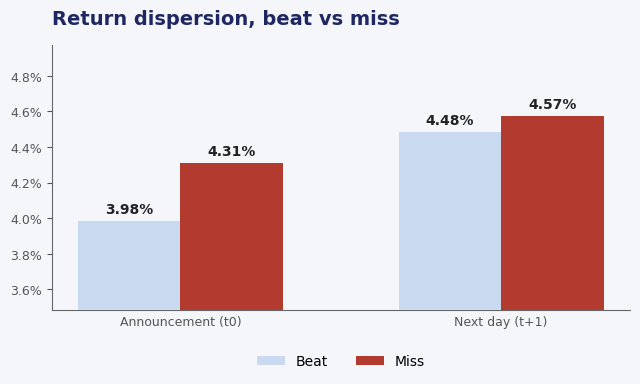

In [10]:
import matplotlib.pyplot as plt
plt.style.use("default")

beat_row = stats.filter(pl.col("beat") == 1).row(0, named=True)
miss_row = stats.filter(pl.col("beat") == 0).row(0, named=True)

labels = ["Announcement (t0)", "Next day (t+1)"]
beat_vals = [beat_row["std_t0"] * 100, beat_row["std_t1"] * 100]
miss_vals = [miss_row["std_t0"] * 100, miss_row["std_t1"] * 100]

x = range(len(labels))
width = 0.32

fig, ax = plt.subplots(figsize=(6.5, 4))
fig.patch.set_facecolor("#F5F6FA")
ax.set_facecolor("#F5F6FA")

bars_beat = ax.bar([i - width / 2 for i in x], beat_vals, width,
                    color="#C9D9F0", label="Beat", zorder=3)
bars_miss = ax.bar([i + width / 2 for i in x], miss_vals, width,
                    color="#B23A2E", label="Miss", zorder=3)

for bars in (bars_beat, bars_miss):
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, h + 0.03, f"{h:.2f}%",
                ha="center", va="bottom", fontsize=10, fontweight="bold", color="#222")

ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=11, color="#333")

ymin = min(beat_vals + miss_vals) - 0.5
ymax = max(beat_vals + miss_vals) + 0.4
ax.set_ylim(ymin, ymax)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.1f}%")
ax.tick_params(axis="both", labelsize=9, colors="#555")
ax.tick_params(axis="x", length=0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["left"].set_color("#666")
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_visible(True)
ax.spines["bottom"].set_color("#666")
ax.spines["bottom"].set_linewidth(0.8)

ax.grid(False)
ax.xaxis.grid(False)
ax.yaxis.grid(False)

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2,
          frameon=False, fontsize=10)

plt.title("Return dispersion, beat vs miss", fontsize=14, fontweight="bold",
          color="#1E2761", loc="left", pad=15)
plt.tight_layout()
plt.savefig("return_dispersion_beat_vs_miss.png", dpi=200, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

In [13]:
df_earnings = pl.read_parquet("../ingestion/data/backup/earnings_delta_backup.parquet").with_columns(
    pl.col("surprisePercentage").cast(pl.Float64, strict=False)
)

merged = merged.join(
    df_earnings.select(["symbol", "reportedDate", "surprisePercentage"]),
    left_on=["symbol", "earnings_date"],
    right_on=["symbol", "reportedDate"],
    how="left",
)

print("surprisePercentage" in merged.columns)  # should print True now

True


In [14]:
import numpy as np

valid = merged.select(["surprisePercentage", "target_return"]).drop_nulls()
r_surprise = np.corrcoef(
    valid["surprisePercentage"].to_numpy(),
    valid["target_return"].to_numpy()
)[0, 1]
print(f"EPS surprise % vs target_return: r = {r_surprise:.3f}")

EPS surprise % vs target_return: r = 0.002


In [18]:
import polars as pl
import numpy as np
import pandas as pd

exclude = ["symbol", "earnings_date", "target_return", "target_direction", "beat"]
all_feature_cols = [c for c in df_model.columns if c not in exclude]
print(f"Total feature columns: {len(all_feature_cols)}")

df_all = df_model.select(all_feature_cols).to_pandas()
df_all = df_all.select_dtypes(include=[np.number])
print(f"Numeric columns: {df_all.shape[1]}")

corr_matrix = df_all.corr()
corr_array = corr_matrix.to_numpy(copy=True)
np.fill_diagonal(corr_array, 0)
corr_matrix_no_diag = pd.DataFrame(corr_array, index=corr_matrix.index, columns=corr_matrix.columns)

high_corr_mask = corr_matrix_no_diag.abs() > 0.95
features_flagged = high_corr_mask.any(axis=1).sum()
print(f"\n{features_flagged} of {df_all.shape[1]} features exceeded |r| > 0.95 with another feature")

independent_features = corr_matrix_no_diag.columns[~high_corr_mask.any(axis=1)]
print(f"\n{len(independent_features)} independent features:")
print(list(independent_features))

Total feature columns: 216
Numeric columns: 216

110 of 216 features exceeded |r| > 0.95 with another feature

106 independent features:
['open_pct_t-10', 'high_pct_t-10', 'low_pct_t-10', 'volume_rel_t-10', 'rsi_t-10', 'roc_t-10', 'bb_pct_b_t-10', 'vwap_pct_t-10', 'open_pct_t-9', 'high_pct_t-9', 'low_pct_t-9', 'volume_rel_t-9', 'rsi_t-9', 'roc_t-9', 'bb_pct_b_t-9', 'vwap_pct_t-9', 'open_pct_t-8', 'high_pct_t-8', 'low_pct_t-8', 'volume_rel_t-8', 'rsi_t-8', 'roc_t-8', 'bb_pct_b_t-8', 'vwap_pct_t-8', 'open_pct_t-7', 'high_pct_t-7', 'low_pct_t-7', 'volume_rel_t-7', 'rsi_t-7', 'roc_t-7', 'bb_pct_b_t-7', 'vwap_pct_t-7', 'open_pct_t-6', 'high_pct_t-6', 'low_pct_t-6', 'volume_rel_t-6', 'rsi_t-6', 'roc_t-6', 'bb_pct_b_t-6', 'vwap_pct_t-6', 'open_pct_t-5', 'high_pct_t-5', 'low_pct_t-5', 'volume_rel_t-5', 'rsi_t-5', 'roc_t-5', 'bb_pct_b_t-5', 'vwap_pct_t-5', 'open_pct_t-4', 'high_pct_t-4', 'low_pct_t-4', 'volume_rel_t-4', 'rsi_t-4', 'roc_t-4', 'bb_pct_b_t-4', 'vwap_pct_t-4', 'open_pct_t-3', 'high

In [19]:
corr_pairs = corr_matrix_no_diag.abs().unstack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) < corr_pairs.index.get_level_values(1)]
top_pairs = corr_pairs.sort_values(ascending=False).head(20)
print(top_pairs)

ema50_200_pct_t-2   ema50_200_pct_t-3    0.999819
ema50_200_pct_t-1   ema50_200_pct_t-2    0.999816
ema50_200_pct_t-4   ema50_200_pct_t-5    0.999815
ema50_200_pct_t-3   ema50_200_pct_t-4    0.999815
ema50_200_pct_t-5   ema50_200_pct_t-6    0.999814
ema50_200_pct_t-10  ema50_200_pct_t-9    0.999812
ema50_200_pct_t-6   ema50_200_pct_t-7    0.999811
ema50_200_pct_t-8   ema50_200_pct_t-9    0.999811
ema50_200_pct_t-7   ema50_200_pct_t-8    0.999808
ema50_200_pct_t-1   ema50_200_pct_t0     0.999726
ema50_200_pct_t+1   ema50_200_pct_t0     0.999617
ema50_200_pct_t-1   ema50_200_pct_t-3    0.999292
ema50_200_pct_t-2   ema50_200_pct_t-4    0.999287
ema50_200_pct_t-3   ema50_200_pct_t-5    0.999280
ema50_200_pct_t-4   ema50_200_pct_t-6    0.999279
ema50_200_pct_t-5   ema50_200_pct_t-7    0.999269
ema50_200_pct_t-10  ema50_200_pct_t-8    0.999268
ema50_200_pct_t-6   ema50_200_pct_t-8    0.999259
ema50_200_pct_t-7   ema50_200_pct_t-9    0.999258
ema50_200_pct_t-2   ema50_200_pct_t0     0.999192


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("default")

# ── reuse cross_indicator_pairs from the last step ─────────────────────────
# for each base indicator, find its single strongest cross-indicator correlation
base_indicators = sorted(set(cross_indicator_pairs["base_a"]) | set(cross_indicator_pairs["base_b"]))

max_corr_per_indicator = {}
for ind in base_indicators:
    mask = (cross_indicator_pairs["base_a"] == ind) | (cross_indicator_pairs["base_b"] == ind)
    subset = cross_indicator_pairs[mask]
    if len(subset) > 0:
        max_corr_per_indicator[ind] = subset["abs_corr"].max()
    else:
        max_corr_per_indicator[ind] = 0.0

# ── also find WHAT each indicator is most correlated with, for labeling ───
label_map = {}
for ind in base_indicators:
    mask = (cross_indicator_pairs["base_a"] == ind) | (cross_indicator_pairs["base_b"] == ind)
    subset = cross_indicator_pairs[mask].sort_values("abs_corr", ascending=False)
    if len(subset) > 0:
        row = subset.iloc[0]
        partner = row["base_b"] if row["base_a"] == ind else row["base_a"]
        label_map[ind] = f"{ind} ↔ {partner}"
    else:
        label_map[ind] = f"{ind} ↔ others"

# ── classify into buckets ───────────────────────────────────────────────
def classify(v):
    if v > 0.9:
        return "Redundant"
    elif v > 0.5:
        return "Related"
    else:
        return "Independent"

results = pd.DataFrame({
    "indicator": base_indicators,
    "max_corr": [max_corr_per_indicator[i] for i in base_indicators],
    "label": [label_map[i] for i in base_indicators],
})
results["category"] = results["max_corr"].apply(classify)
results = results.sort_values("max_corr", ascending=False)

print(results[["indicator", "label", "max_corr", "category"]].to_string(index=False))

# ── plot ────────────────────────────────────────────────────────────────
color_map = {"Redundant": "#B23A2E", "Related": "#D9A82B", "Independent": "#3C8F6B"}
colors = results["category"].map(color_map)

fig, ax = plt.subplots(figsize=(6.5, 5))
fig.patch.set_facecolor("#F5F6FA")
ax.set_facecolor("#F5F6FA")

bars = ax.barh(results["label"], results["max_corr"], color=colors, height=0.6, zorder=3)
ax.invert_yaxis()

for bar, val in zip(bars, results["max_corr"]):
    ax.text(bar.get_width() + 0.015, bar.get_y() + bar.get_height() / 2,
             f"{val:.2f}", va="center", fontsize=9, fontweight="bold", color="#222")

ax.set_xlim(0, 1.08)
ax.tick_params(axis="both", labelsize=9, colors="#333")
ax.tick_params(axis="y", length=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["left"].set_color("#666")
ax.spines["bottom"].set_visible(True)
ax.spines["bottom"].set_color("#666")
ax.grid(False)

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=c, label=l) for l, c in color_map.items()]
ax.legend(handles=legend_elems, loc="upper center", bbox_to_anchor=(0.5, -0.1),
          ncol=3, frameon=False, fontsize=10)

plt.title("Which signals are actually distinct?", fontsize=14, fontweight="bold",
          color="#1E2761", loc="left", pad=15)
plt.tight_layout()
plt.savefig("signal_distinctness.png", dpi=200, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

NameError: name 'cross_indicator_pairs' is not defined

In [21]:
import polars as pl
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt
plt.style.use("default")

# ── select feature columns + target ────────────────────────────────────────
exclude = ["symbol", "earnings_date", "target_return", "target_direction", "beat"]
feature_cols = [c for c in df_model.columns if c not in exclude]

df_pd = df_model.select(feature_cols + ["target_direction"]).to_pandas()
df_pd = df_pd.dropna()  # mutual_info_classif can't handle NaNs

X = df_pd[feature_cols].select_dtypes(include=[np.number])
y = df_pd["target_direction"]

print(f"Rows used: {len(X):,}, features: {X.shape[1]}")

# ── compute mutual information for every feature (can take a minute) ──────
mi_scores = mutual_info_classif(X, y, discrete_features=False, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print(mi_series.head(20))

Rows used: 23,794, features: 216
bb_width_t-8      0.007814
macd_hist_t-9     0.007057
vwap_pct_t-7      0.006705
low_pct_t-8       0.006570
high_pct_t-6      0.006268
ema50_pct_t-2     0.006145
obv_zscore_t0     0.006002
bb_pct_b_t-10     0.005789
ema200_pct_t-9    0.005788
low_pct_t-6       0.005528
low_pct_t-1       0.005251
ema200_pct_t-4    0.005152
vwap_pct_t-2      0.004854
open_pct_t-4      0.004851
volume_rel_t-7    0.004719
atr_t-8           0.004683
macd_hist_t-4     0.004646
low_pct_t-9       0.004497
sigma_t-10        0.004455
rsi_t-6           0.004451
dtype: float64


In [22]:
import re

def get_base_indicator(col_name):
    return re.sub(r"_t[+-]?\d+$", "", col_name)

mi_df = mi_series.reset_index()
mi_df.columns = ["feature", "mi_score"]
mi_df["base_indicator"] = mi_df["feature"].apply(get_base_indicator)

# take the max MI score per base indicator across all its lags
mi_by_indicator = mi_df.groupby("base_indicator")["mi_score"].max().sort_values(ascending=False)
print(mi_by_indicator)

base_indicator
bb_width         0.007814
macd_hist        0.007057
vwap_pct         0.006705
low_pct          0.006570
high_pct         0.006268
ema50_pct        0.006145
obv_zscore       0.006002
bb_pct_b         0.005789
ema200_pct       0.005788
open_pct         0.004851
volume_rel       0.004719
atr              0.004683
sigma            0.004455
rsi              0.004451
adx              0.004088
macd             0.003538
ema50_200_pct    0.003492
roc              0.001775
Name: mi_score, dtype: float64


In [23]:
# ── map indicators to display labels + tiers, based on your MI ranking ────
# adjust these groupings once you see the real mi_by_indicator values above
label_groups = {
    "SMA-50 ratio":        ["ema50_pct"],       # or sma50_ratio if that's your actual column name
    "RSI":                 ["rsi"],
    "Volume change":       ["volume_rel"],
    "Low price (t0)":      ["low_pct"],
    "ROC, ADX":            ["roc", "adx"],
    "OBV, VWAP":           ["obv_zscore", "vwap_pct"],
    "Sentiment / fundamentals": ["pos_prob", "neg_prob", "eps_growth_qoq", "roe"],
}

plot_data = []
for label, indicators in label_groups.items():
    scores = [mi_by_indicator.get(i, 0) for i in indicators if i in mi_by_indicator.index]
    if scores:
        plot_data.append({"label": label, "score": max(scores)})

plot_df = pd.DataFrame(plot_data).sort_values("score", ascending=False)
print(plot_df)

            label     score
5       OBV, VWAP  0.006705
3  Low price (t0)  0.006570
0    SMA-50 ratio  0.006145
2   Volume change  0.004719
1             RSI  0.004451
4        ROC, ADX  0.004088


In [9]:
# Class balance — using beat column from pipeline
beat_dist = df_model.group_by("beat").len().sort("beat")
print("Overall class distribution:")
print(beat_dist)

beat_rate = modeling["beat"].mean()
print(f"\nOverall beat rate: {beat_rate:.1%}")

# Beat rate by symbol (check for per-stock imbalance)
per_stock = modeling.group_by("symbol").agg([
    pl.col("beat").mean().alias("beat_rate"),
    pl.len().alias("events"),
]).sort("beat_rate")

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(per_stock["beat_rate"].to_list(), bins=20, edgecolor="black")
ax.axvline(x=beat_rate, color="red", linestyle="--", label=f"Overall: {beat_rate:.1%}")
ax.set_title("Beat Rate Distribution Across Stocks")
ax.set_xlabel("Beat Rate")
ax.set_ylabel("Number of Stocks")
ax.legend()
plt.tight_layout()
plt.show()

NameError: name 'modeling' is not defined

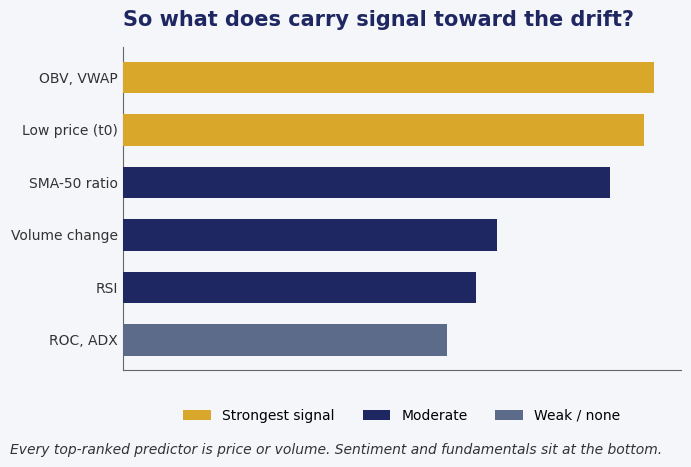

In [24]:
def tier(v, top_cutoff, mid_cutoff):
    if v >= top_cutoff:
        return "Strongest signal"
    elif v >= mid_cutoff:
        return "Moderate"
    else:
        return "Weak / none"

scores_sorted = plot_df["score"].values
top_cutoff = scores_sorted[1]   # e.g. 2nd highest score as the "strongest" cutoff
mid_cutoff = scores_sorted[-2]  # adjust manually based on visual grouping you want

plot_df["tier"] = plot_df["score"].apply(lambda v: tier(v, top_cutoff, mid_cutoff))

color_map = {"Strongest signal": "#D9A82B", "Moderate": "#1E2761", "Weak / none": "#5C6B8A"}
colors = plot_df["tier"].map(color_map)

fig, ax = plt.subplots(figsize=(7, 4.5))
fig.patch.set_facecolor("#F5F6FA")
ax.set_facecolor("#F5F6FA")

bars = ax.barh(plot_df["label"], plot_df["score"], color=colors, height=0.6, zorder=3)
ax.invert_yaxis()

ax.tick_params(axis="both", labelsize=10, colors="#333")
ax.tick_params(axis="y", length=0)
ax.set_xticks([])  # reference chart has no x-axis labels, just relative bar length
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["left"].set_color("#666")
ax.spines["bottom"].set_visible(True)
ax.spines["bottom"].set_color("#666")
ax.grid(False)

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=c, label=l) for l, c in color_map.items()]
ax.legend(handles=legend_elems, loc="upper center", bbox_to_anchor=(0.5, -0.08),
          ncol=3, frameon=False, fontsize=10)

plt.title("So what does carry signal toward the drift?", fontsize=15, fontweight="bold",
          color="#1E2761", loc="left", pad=15)
plt.figtext(0.02, -0.02,
            "Every top-ranked predictor is price or volume. Sentiment and fundamentals sit at the bottom.",
            fontsize=10, style="italic", color="#333", ha="left")

plt.tight_layout()
plt.savefig("mi_signal_ranking.png", dpi=200, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

Rows used: 24,048, features: 228
base_indicator
bb_width              0.007812
high_pct              0.005952
obv_zscore            0.005948
macd_hist             0.005754
vwap_pct              0.005628
low_pct               0.005588
ema50_pct             0.005517
ema200_pct            0.005384
bb_pct_b              0.005298
atr                   0.005261
volume_rel            0.004943
sigma                 0.004825
open_pct              0.004624
rsi                   0.004503
adx                   0.004244
fcf_margin_qoq        0.003923
roe_qoq               0.003707
macd                  0.003495
ema50_200_pct         0.003448
eps_growth_qoq        0.002717
pos_prob              0.002589
roc                   0.002555
fcf_margin            0.002140
neg_prob              0.001979
revenue_growth_qoq    0.000971
gross_margin_qoq      0.000111
gross_margin          0.000000
debt_to_equity_qoq    0.000000
debt_to_equity        0.000000
roe                   0.000000
Name: mi_score, dtype:

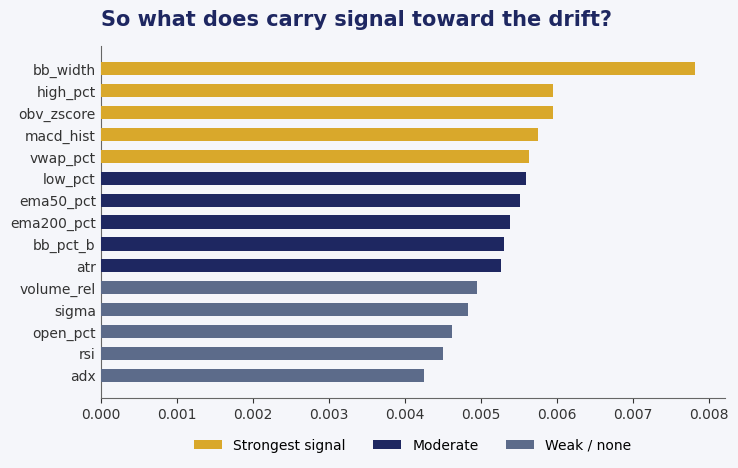

In [28]:
import polars as pl
import numpy as np
import pandas as pd
import re
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt
plt.style.use("default")

# ── 1. features + target — impute instead of dropping rows ────────────────
exclude = ["symbol", "earnings_date", "target_return", "target_direction", "beat"]
feature_cols = [c for c in df_model.columns if c not in exclude]

df_pd = df_model.select(feature_cols + ["target_direction"]).to_pandas()
df_pd = df_pd.fillna(df_pd.median(numeric_only=True))
df_pd = df_pd.dropna(subset=["target_direction"])  # only drop if target itself missing

X = df_pd[feature_cols].select_dtypes(include=[np.number])
y = df_pd["target_direction"]
print(f"Rows used: {len(X):,}, features: {X.shape[1]}")

# ── 2. mutual information per raw feature ──────────────────────────────────
mi_scores = mutual_info_classif(X, y, discrete_features=False, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# ── 3. collapse to one score per base indicator ────────────────────────────
def get_base_indicator(col_name):
    return re.sub(r"_t[+-]?\d+$", "", col_name)

mi_df = mi_series.reset_index()
mi_df.columns = ["feature", "mi_score"]
mi_df["base_indicator"] = mi_df["feature"].apply(get_base_indicator)

mi_by_indicator = (
    mi_df.groupby("base_indicator")["mi_score"]
    .max()
    .sort_values(ascending=False)
)
print(mi_by_indicator)

# ── 4. trim to top 15, tier by actual distribution within that top 15 ─────
plot_df = mi_by_indicator.reset_index()
plot_df.columns = ["indicator", "mi_score"]
plot_df = plot_df.sort_values("mi_score", ascending=False).head(15)

n = len(plot_df)
top_cut = plot_df["mi_score"].iloc[max(0, n // 3 - 1)]
mid_cut = plot_df["mi_score"].iloc[max(0, 2 * n // 3 - 1)]

def tier(v):
    if v >= top_cut:
        return "Strongest signal"
    elif v >= mid_cut:
        return "Moderate"
    else:
        return "Weak / none"

plot_df["tier"] = plot_df["mi_score"].apply(tier)
print(plot_df)

# ── 5. plot ─────────────────────────────────────────────────────────────
color_map = {"Strongest signal": "#D9A82B", "Moderate": "#1E2761", "Weak / none": "#5C6B8A"}
colors = plot_df["tier"].map(color_map)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
fig.patch.set_facecolor("#F5F6FA")
ax.set_facecolor("#F5F6FA")

bars = ax.barh(plot_df["indicator"], plot_df["mi_score"], color=colors, height=0.6, zorder=3)
ax.invert_yaxis()

ax.tick_params(axis="both", labelsize=10, colors="#333")
ax.tick_params(axis="y", length=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["left"].set_color("#666")
ax.spines["bottom"].set_visible(True)
ax.spines["bottom"].set_color("#666")
ax.grid(False)

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=c, label=l) for l, c in color_map.items()]
ax.legend(handles=legend_elems, loc="upper center", bbox_to_anchor=(0.5, -0.08),
          ncol=3, frameon=False, fontsize=10)

plt.title("So what does carry signal toward the drift?", fontsize=15, fontweight="bold",
          color="#1E2761", loc="left", pad=15)
plt.tight_layout()
plt.savefig("mi_signal_ranking.png", dpi=200, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

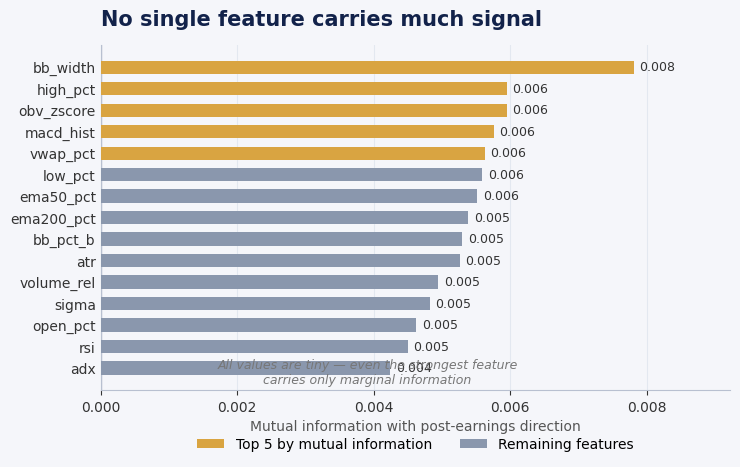

In [29]:
# ── 4. trim to top 15 (keep your steps 1–3 exactly as they are) ──────────
plot_df = mi_by_indicator.reset_index()
plot_df.columns = ["indicator", "mi_score"]
plot_df = plot_df.sort_values("mi_score", ascending=False).head(15)
plot_df = plot_df.reset_index(drop=True)

# ── 5. plot ──────────────────────────────────────────────────────────────
NAVY  = "#12224A"
GOLD  = "#D9A441"
MUTED = "#8A97AD"
BG    = "#F5F6FA"

# Colour = rank position, not a fake category. Top 5 highlighted; the rest
# muted. No invented "moderate / weak" break, because the values don't separate.
colors = [GOLD if i < 5 else MUTED for i in range(len(plot_df))]

fig, ax = plt.subplots(figsize=(7.5, 4.8))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bars = ax.barh(plot_df["indicator"], plot_df["mi_score"],
               color=colors, height=0.62, zorder=3)
ax.invert_yaxis()

for b, v in zip(bars, plot_df["mi_score"]):
    ax.text(v + 0.00008, b.get_y() + b.get_height() / 2,
            f"{v:.3f}", va="center", ha="left", fontsize=9, color="#333")

ax.set_xlabel("Mutual information with post-earnings direction", fontsize=10, color="#555")
ax.tick_params(axis="both", labelsize=10, colors="#333")
ax.tick_params(axis="y", length=0)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)
for sp in ["left", "bottom"]:
    ax.spines[sp].set_visible(True)
    ax.spines[sp].set_color("#B8C0D0")
ax.set_xlim(0, plot_df["mi_score"].max() * 1.18)
ax.grid(axis="x", color="#E3E8F0", zorder=0)

best = plot_df["mi_score"].max()
ax.axvline(0, color="#B8C0D0", lw=1)
ax.text(best * 0.5, len(plot_df) - 0.3,
        "All values are tiny — even the strongest feature\ncarries only marginal information",
        fontsize=9, style="italic", color="#777", ha="center")

from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor=GOLD,  label="Top 5 by mutual information"),
    Patch(facecolor=MUTED, label="Remaining features"),
]
ax.legend(handles=legend_elems, loc="upper center", bbox_to_anchor=(0.5, -0.10),
          ncol=2, frameon=False, fontsize=10)

plt.title("No single feature carries much signal",
          fontsize=15, fontweight="bold", color=NAVY, loc="left", pad=14)
plt.tight_layout()
plt.savefig("mi_signal_ranking.png", dpi=200, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

family
Volatility       0.005799
Volume           0.005446
Price / trend    0.005163
Momentum         0.004110
Sentiment        0.002284
Fundamentals     0.001357
Name: mi_score, dtype: float64


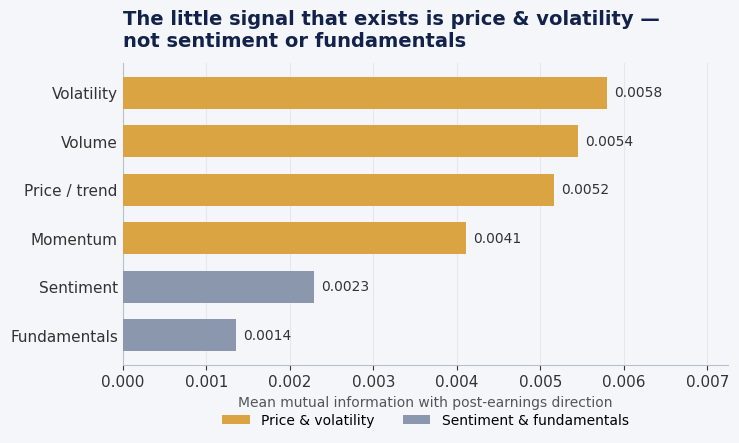

In [30]:
# ── 4. map every feature to a family, then aggregate MI ──────────────────
FAMILY_RULES = [
    ("Volatility",    ["bb_width", "bb_pct_b", "atr", "sigma", "vix", "bollinger"]),
    ("Price / trend", ["high_pct", "low_pct", "open_pct", "close", "vwap",
                        "ema", "sma", "price"]),
    ("Volume",        ["obv", "volume", "vol_"]),
    ("Momentum",      ["macd", "rsi", "adx", "roc", "momentum"]),
    ("Sentiment",     ["finbert", "sentiment", "news", "pos_prob", "neg_prob", "tone"]),
    ("Fundamentals",  ["eps", "revenue", "margin", "roe", "debt", "fcf", "growth"]),
]

def to_family(name):
    n = name.lower()
    for fam, keys in FAMILY_RULES:
        if any(k in n for k in keys):
            return fam
    return "Other"

fam_df = mi_by_indicator.reset_index()
fam_df.columns = ["indicator", "mi_score"]
fam_df["family"] = fam_df["indicator"].apply(to_family)

fam_mi = fam_df.groupby("family")["mi_score"].mean().sort_values(ascending=False)
for fam, _ in FAMILY_RULES:
    if fam not in fam_mi.index:
        fam_mi[fam] = 0.0
fam_mi = fam_mi.drop(labels=["Other"], errors="ignore").sort_values(ascending=False)
print(fam_mi)

# ── 5. plot ──────────────────────────────────────────────────────────────
NAVY, GOLD, MUTED, BG = "#12224A", "#D9A441", "#8A97AD", "#F5F6FA"
TECHNICAL = {"Volatility", "Price / trend", "Volume", "Momentum"}
colors = [GOLD if fam in TECHNICAL else MUTED for fam in fam_mi.index]

fig, ax = plt.subplots(figsize=(7.5, 4.6))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

bars = ax.barh(fam_mi.index, fam_mi.values, color=colors, height=0.66, zorder=3)
ax.invert_yaxis()
for b, v in zip(bars, fam_mi.values):
    ax.text(v + fam_mi.max() * 0.015, b.get_y() + b.get_height()/2,
            f"{v:.4f}", va="center", ha="left", fontsize=10, color="#333")

ax.set_xlabel("Mean mutual information with post-earnings direction", fontsize=10, color="#555")
ax.tick_params(axis="both", labelsize=11, colors="#333")
ax.tick_params(axis="y", length=0)
for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
for sp in ["left", "bottom"]:
    ax.spines[sp].set_visible(True); ax.spines[sp].set_color("#B8C0D0")
ax.set_xlim(0, fam_mi.max() * 1.25)
ax.grid(axis="x", color="#E3E8F0", zorder=0)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=GOLD, label="Price & volatility"),
                   Patch(facecolor=MUTED, label="Sentiment & fundamentals")],
          loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2,
          frameon=False, fontsize=10)

plt.title("The little signal that exists is price & volatility —\nnot sentiment or fundamentals",
          fontsize=14, fontweight="bold", color=NAVY, loc="left", pad=12)
plt.tight_layout()
plt.savefig("mi_by_family.png", dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()